In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon
import numpy as np
import seaborn as sns
import ast
from pycocotools import mask as maskUtils
from PIL import Image
import re
import cv2
import json
import os

### Please use the folders as specified below only. There are different folders and paths. Use the exact one as mentioned below.

In [3]:
annotations_path = "Abhinaya_result_coco.json"   
images_folder = "Abhinaya_data" 
save_image_folder = "AbhinayaImages/images"
save_mask_folder = "AbhinayaImages/masks"

In [4]:
os.makedirs(save_image_folder, exist_ok=True)
os.makedirs(save_mask_folder, exist_ok=True)

# Load annotations
with open(annotations_path) as f:
    data = json.load(f)

# Class mapping
class_map = {"Background": 0, "Enamel": 1, "Dentine": 2, "Pulp": 3}

print(f"Total images in JSON: {len(data['images'])}")
print(f"Total annotations in JSON: {len(data['annotations'])}")
print(f"Categories: {[(c['id'], c['name']) for c in data['categories']]}\n")

for local_file in os.listdir(images_folder):
    if not local_file.lower().endswith((".png", ".jpg", ".jpeg")):
        continue
    
    local_name = os.path.basename(local_file)
    image_path = os.path.join(images_folder, local_name)
    
    # Regex match to JSON file_name
    pattern = re.compile(re.escape(local_name), re.IGNORECASE)
    image_info = next((img for img in data["images"] if pattern.search(img["file_name"])), None)
    
    if image_info is None:
        print(f"⚠️ No match for {local_name}")
        continue
    
    print(f"{'='*60}")
    print(f"Processing: {local_name}")
    print(f"Image ID: {image_info['id']}")
    
    # Load image and convert to grayscale
    image = np.array(Image.open(image_path).convert("L"))
    h, w = image.shape
    print(f"Image dimensions: {h}x{w}")
    
    # Initialize mask (integer mask for multi-class segmentation)
    mask = np.zeros((h, w), dtype=np.uint8)
    
    ann_list = [a for a in data["annotations"] if a["image_id"] == image_info["id"]]
    
    if not ann_list:
        print(f"⚠️ No annotations for {local_name}")
        continue
    
    print(f"Found {len(ann_list)} annotations")
    
    # Decode polygons or RLEs
    masks_temp = {"Enamel": np.zeros((h, w), dtype=bool),
                  "Dentine": np.zeros((h, w), dtype=bool),
                  "Pulp": np.zeros((h, w), dtype=bool)}
    
    for idx, ann_item in enumerate(ann_list):
        cat_id = ann_item["category_id"]
        cat_name = next((c["name"] for c in data["categories"] if c["id"] == cat_id), None)
        
        if cat_name not in masks_temp:
            print(f"  ⚠️ Category '{cat_name}' not in masks_temp, skipping")
            continue
        
        seg = ann_item.get("segmentation", None)
        if not seg:
            print(f"  ⚠️ No segmentation data for annotation {idx+1}")
            continue
        
        try:
            # Polygon format
            if isinstance(seg, list):
                rles = maskUtils.frPyObjects(seg, h, w)
                rle = maskUtils.merge(rles)
                m = maskUtils.decode(rle)
                if m.ndim == 3:
                    m = np.any(m, axis=2)
                m = m.astype(bool)
            # RLE format
            elif isinstance(seg, dict):
                m = maskUtils.decode(seg).astype(bool)
            else:
                print(f"  ⚠️ Unknown segmentation format for annotation {idx+1}")
                continue
        
            masks_temp[cat_name] |= m
        
        except Exception as e:
            print(f"  ⚠️ Could not decode {cat_name}: {e}")
    
    # Check totals before priority logic
    print(f"Before priority logic:")
    print(f"  Enamel: {masks_temp['Enamel'].sum()} pixels")
    print(f"  Dentine: {masks_temp['Dentine'].sum()} pixels")
    print(f"  Pulp: {masks_temp['Pulp'].sum()} pixels")
    
    # Priority logic: Pulp > Dentine > Enamel
    mask[masks_temp["Pulp"]] = class_map["Pulp"]
    dentine_only = np.logical_and(masks_temp["Dentine"], ~masks_temp["Pulp"])
    mask[dentine_only] = class_map["Dentine"]
    enamel_only = np.logical_and(masks_temp["Enamel"], 
                                  ~np.logical_or(masks_temp["Dentine"], masks_temp["Pulp"]))
    mask[enamel_only] = class_map["Enamel"]
    
    # Check final mask
    unique, counts = np.unique(mask, return_counts=True)
    print(f"Final mask distribution:")
    for val, count in zip(unique, counts):
        class_name = [k for k, v in class_map.items() if v == val][0]
        print(f"  {class_name} ({val}): {count} pixels ({100*count/(h*w):.2f}%)")
    
    # Save image
    Image.fromarray(image).save(os.path.join(save_image_folder, local_name))
    
    # Save mask with proper scaling for visualization
    mask_filename = os.path.splitext(local_name)[0] + "_mask.png"
    mask_visual = (mask * 85).astype(np.uint8)  # Scale 0-3 to 0-255
    
    print(f"Mask visual range: min={mask_visual.min()}, max={mask_visual.max()}")
    print(f"Mask visual unique values: {np.unique(mask_visual)}")
    
    Image.fromarray(mask_visual).save(os.path.join(save_mask_folder, mask_filename))
    print(f"✅ Saved: {local_name}\n")

print("\n" + "="*60)
print("PROCESSING COMPLETE")
print(f"Saved images to: {save_image_folder}")
print(f"Saved masks to: {save_mask_folder}")

Total images in JSON: 88
Total annotations in JSON: 601
Categories: [(1, 'Enamel'), (2, 'Dentine'), (3, 'Pulp')]

Processing: RVG_258.png
Image ID: 9
Image dimensions: 790x1100
Found 6 annotations
Before priority logic:
  Enamel: 86601 pixels
  Dentine: 295694 pixels
  Pulp: 46553 pixels
Final mask distribution:
  Background (0): 486705 pixels (56.01%)
  Enamel (1): 86601 pixels (9.97%)
  Dentine (2): 249141 pixels (28.67%)
  Pulp (3): 46553 pixels (5.36%)
Mask visual range: min=0, max=255
Mask visual unique values: [  0  85 170 255]
✅ Saved: RVG_258.png

Processing: RVG_259.png
Image ID: 10
Image dimensions: 1100x790
Found 9 annotations
Before priority logic:
  Enamel: 94188 pixels
  Dentine: 309122 pixels
  Pulp: 43513 pixels
Final mask distribution:
  Background (0): 465690 pixels (53.59%)
  Enamel (1): 94188 pixels (10.84%)
  Dentine (2): 265609 pixels (30.56%)
  Pulp (3): 43513 pixels (5.01%)
Mask visual range: min=0, max=255
Mask visual unique values: [  0  85 170 255]
✅ Saved: R

### The below code is a trial to shift all enamel polygon points by some N pixels down. This was to overlap the enamel with the dentine but it was not resulting in the best output.

In [10]:
save_image_folder = "att_unet_shifted_8/images"
save_mask_folder = "att_unet_shifted_8/masks"

In [11]:
os.makedirs(save_image_folder, exist_ok=True)
os.makedirs(save_mask_folder, exist_ok=True)

# Load annotations
with open(annotations_path) as f:
    data = json.load(f)

# Class mapping
class_map = {"Background": 0, "Enamel": 1, "Dentine": 2, "Pulp": 3}

SHIFT_Y = 8   # << SHIFT ENAMEL DOWN BY 5 PIXELS >>

print(f"Total images in JSON: {len(data['images'])}")
print(f"Total annotations in JSON: {len(data['annotations'])}")
print(f"Categories: {[(c['id'], c['name']) for c in data['categories']]}\n")

for local_file in os.listdir(images_folder):
    if not local_file.lower().endswith((".png", ".jpg", ".jpeg")):
        continue
    
    local_name = os.path.basename(local_file)
    image_path = os.path.join(images_folder, local_name)
    
    # Match JSON entry
    pattern = re.compile(re.escape(local_name), re.IGNORECASE)
    image_info = next((img for img in data["images"] if pattern.search(img["file_name"])), None)
    
    if image_info is None:
        print(f"⚠️ No match for {local_name}")
        continue
    
    print(f"{'='*60}")
    print(f"Processing: {local_name}")
    
    image = np.array(Image.open(image_path).convert("L"))
    h, w = image.shape
    
    mask = np.zeros((h, w), dtype=np.uint8)
    
    ann_list = [a for a in data["annotations"] if a["image_id"] == image_info["id"]]
    if not ann_list:
        print(f"⚠️ No annotations for {local_name}")
        continue
    
    masks_temp = {
        "Enamel": np.zeros((h, w), dtype=bool),
        "Dentine": np.zeros((h, w), dtype=bool),
        "Pulp": np.zeros((h, w), dtype=bool)
    }
    
    # ------------------ PROCESS ANNOTATIONS ------------------
    for idx, ann_item in enumerate(ann_list):
        cat_id = ann_item["category_id"]
        cat_name = next((c["name"] for c in data["categories"] if c["id"] == cat_id), None)
        
        if cat_name not in masks_temp:
            continue
        
        seg = ann_item.get("segmentation", None)
        if seg is None:
            continue
        
        try:
            # ---------------- POLYGON FORMAT ----------------
            if isinstance(seg, list):
                shifted_seg = []

                for poly in seg:
                    if len(poly) % 2 != 0:
                        continue

                    new_poly = []
                    for i in range(0, len(poly), 2):
                        x = poly[i]
                        y = poly[i+1]

                        # SHIFT ONLY ENAMEL
                        if cat_name == "Enamel":
                            y += SHIFT_Y

                        # clamp inside bounds
                        x = max(0, min(w - 1, x))
                        y = max(0, min(h - 1, y))

                        new_poly.extend([x, y])

                    if len(new_poly) >= 6:
                        shifted_seg.append(new_poly)

                if len(shifted_seg) == 0:
                    m = np.zeros((h, w), dtype=bool)
                else:
                    rles = maskUtils.frPyObjects(shifted_seg, h, w)
                    rle = maskUtils.merge(rles)
                    m = maskUtils.decode(rle).astype(bool)

            # ---------------- RLE FORMAT ----------------
            elif isinstance(seg, dict):
                m = maskUtils.decode(seg).astype(bool)
            else:
                continue

            masks_temp[cat_name] |= m
        
        except Exception as e:
            print(f"⚠️ Error decoding {cat_name}: {e}")
    
    # ---------------- PRIORITY MASK ----------------
    mask[masks_temp["Pulp"]] = class_map["Pulp"]

    dentine_only = masks_temp["Dentine"] & ~masks_temp["Pulp"]
    mask[dentine_only] = class_map["Dentine"]

    enamel_only = masks_temp["Enamel"] & ~(masks_temp["Dentine"] | masks_temp["Pulp"])
    mask[enamel_only] = class_map["Enamel"]
    
    # ---------------- SAVE INPUT IMAGE ----------------
    Image.fromarray(image).save(os.path.join(save_image_folder, local_name))
    
    # ---------------- SAVE TRUE MASK (0,1,2,3) ----------------
    mask_true_filename = os.path.splitext(local_name)[0] + "_mask.png"
    Image.fromarray(mask, mode="L").save(os.path.join(save_mask_folder, mask_true_filename))

    # ---------------- SAVE VISUAL MASK (0–255) ----------------
    mask_visual = (mask * 85).astype(np.uint8)
    visual_filename = os.path.splitext(local_name)[0] + "_mask_visual.png"
    Image.fromarray(mask_visual).save(os.path.join(save_mask_folder, visual_filename))

    print(f"Saved TRUE mask values: {np.unique(mask)}")
    print(f"Saved visual mask values: {np.unique(mask_visual)}")
    print(f"✅ Saved masks for: {local_name}\n")

print("\n" + "="*60)
print("PROCESSING COMPLETE")


Total images in JSON: 88
Total annotations in JSON: 699
Categories: [(1, 'Pulp'), (2, 'Dentine'), (3, 'Enamel')]

Processing: RVG_1.png
Saved TRUE mask values: [0 1 2 3]
Saved visual mask values: [  0  85 170 255]
✅ Saved masks for: RVG_1.png

Processing: RVG_10.png
Saved TRUE mask values: [0 1 2 3]
Saved visual mask values: [  0  85 170 255]
✅ Saved masks for: RVG_10.png

Processing: RVG_100.png
Saved TRUE mask values: [0 1 2 3]
Saved visual mask values: [  0  85 170 255]
✅ Saved masks for: RVG_100.png

Processing: RVG_101.png
Saved TRUE mask values: [0 1 2 3]
Saved visual mask values: [  0  85 170 255]
✅ Saved masks for: RVG_101.png

Processing: RVG_102.png
Saved TRUE mask values: [0 1 2 3]
Saved visual mask values: [  0  85 170 255]
✅ Saved masks for: RVG_102.png

Processing: RVG_103.png
Saved TRUE mask values: [0 1 2 3]
Saved visual mask values: [  0  85 170 255]
✅ Saved masks for: RVG_103.png

Processing: RVG_104.png
Saved TRUE mask values: [0 1 2 3]
Saved visual mask values: [  0

Found 88 masks
RVG_100_mask_visual.png: min=0, max=255, unique=[  0  85 170 255]
RVG_101_mask_visual.png: min=0, max=255, unique=[  0  85 170 255]
RVG_102_mask_visual.png: min=0, max=255, unique=[  0  85 170 255]
RVG_103_mask_visual.png: min=0, max=255, unique=[  0  85 170 255]
RVG_104_mask_visual.png: min=0, max=255, unique=[  0  85 170 255]
RVG_105_mask_visual.png: min=0, max=255, unique=[  0  85 170 255]
RVG_106_mask_visual.png: min=0, max=255, unique=[  0  85 170 255]
RVG_107_mask_visual.png: min=0, max=255, unique=[  0  85 170 255]
RVG_108_mask_visual.png: min=0, max=255, unique=[  0  85 170 255]
RVG_109_mask_visual.png: min=0, max=255, unique=[  0  85 170 255]
RVG_10_mask_visual.png: min=0, max=255, unique=[  0  85 170 255]
RVG_110_mask_visual.png: min=0, max=255, unique=[  0  85 170 255]
RVG_111_mask_visual.png: min=0, max=255, unique=[  0  85 170 255]
RVG_112_mask_visual.png: min=0, max=255, unique=[  0  85 170 255]
RVG_113_mask_visual.png: min=0, max=255, unique=[  0  85 170 2

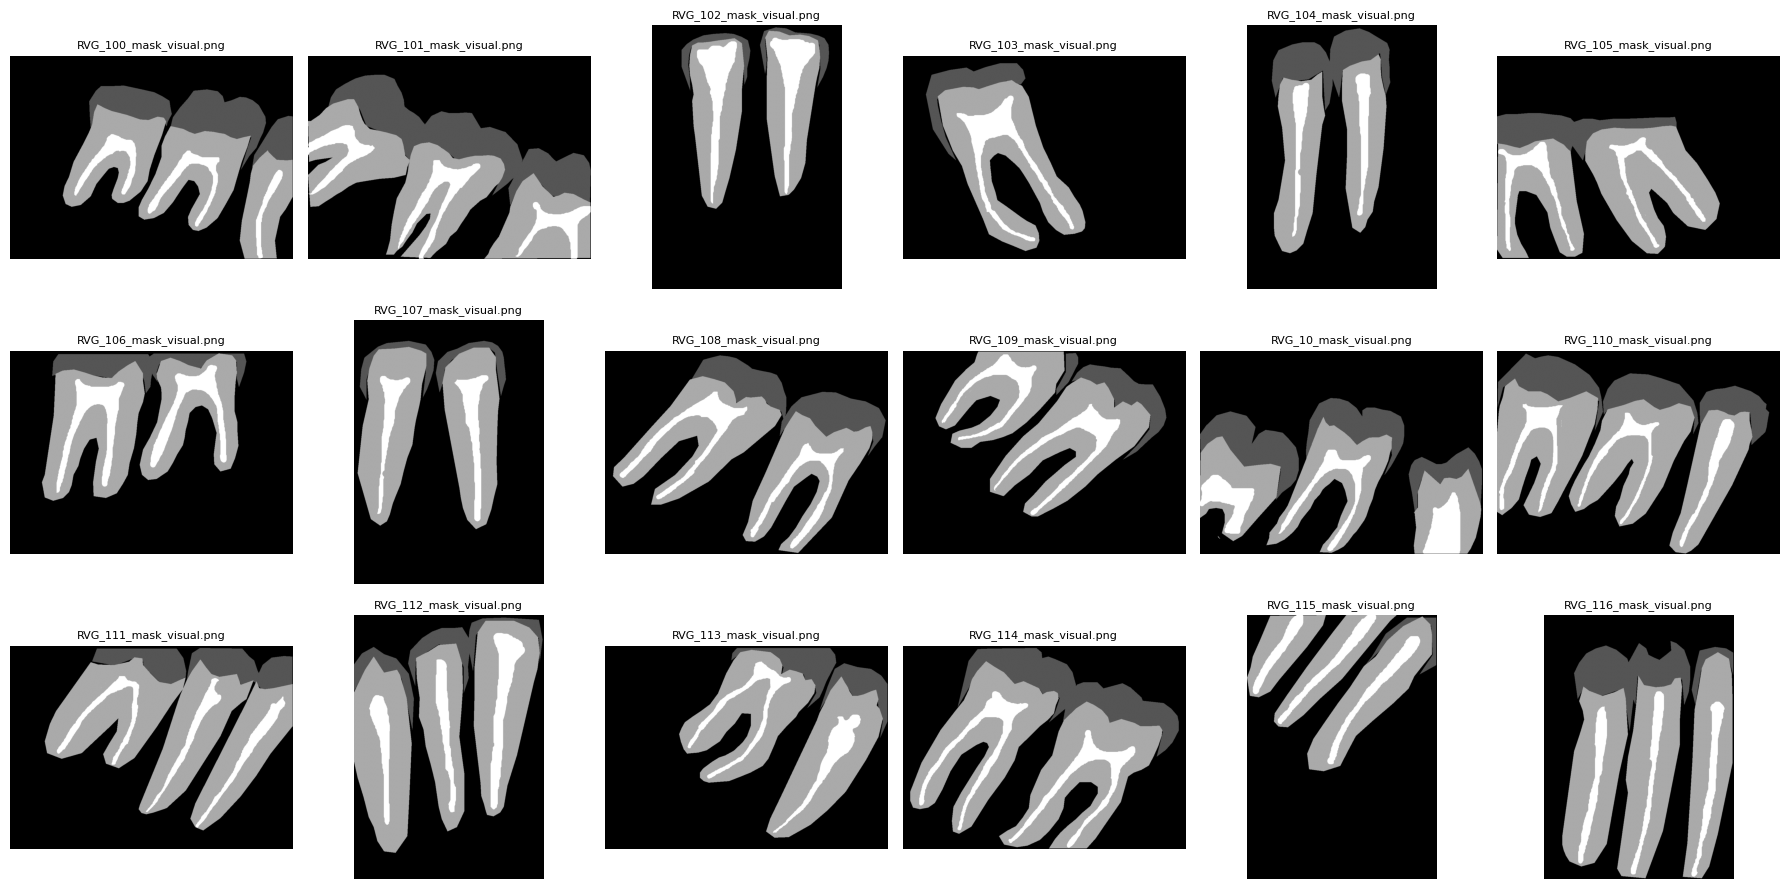


✅ Saved visualization as 'all_masks_grid.png'


In [12]:
# Get all mask files
mask_files = [f for f in os.listdir(save_mask_folder) if f.endswith('_mask_visual.png')]

print(f"Found {len(mask_files)} masks")

# Create 3x6 grid
fig, axes = plt.subplots(3, 6, figsize=(18, 9))
axes = axes.flatten()

for idx, mask_file in enumerate(mask_files):
    if idx >= 18:  # Safety check
        break
    
    # Load mask
    mask_path = os.path.join(save_mask_folder, mask_file)
    mask = np.array(Image.open(mask_path))
    
    # Display
    axes[idx].imshow(mask, cmap='gray', vmin=0, vmax=255)
    axes[idx].set_title(mask_file.replace('_mask.png', ''), fontsize=8)
    axes[idx].axis('off')
    
    # Print info
    print(f"{mask_file}: min={mask.min()}, max={mask.max()}, unique={np.unique(mask)}")

# Hide the last empty subplot
axes[17].axis('off')

plt.tight_layout()
plt.savefig('all_masks_grid.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n✅ Saved visualization as 'all_masks_grid.png'")